In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("List of Countries by Sugarcane Production.csv")

In [3]:
df.head(103)

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879
...,...,...,...,...,...,...,...
98,98,Lebanon,Asia,97,16,3,"28.386,4"
99,99,Djibouti,Africa,53,51,NaN,NaN
100,100,Singapore,Asia,50,9,2,25
101,101,Samoa,Oceania,12,6,1,"11.949,8"


# Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Unnamed: 0                  103 non-null    int64 
 1   Country                     103 non-null    object
 2   Continent                   103 non-null    object
 3   Production (Tons)           103 non-null    object
 4   Production per Person (Kg)  103 non-null    object
 5   Acreage (Hectare)           102 non-null    object
 6   Yield (Kg / Hectare)        102 non-null    object
dtypes: int64(1), object(6)
memory usage: 5.8+ KB


In [5]:
df['Production (Tons)'] = df['Production (Tons)'].str.replace('.' , '')    # value replacing
df['Production per Person (Kg)'] = df['Production per Person (Kg)'].str.replace('.' , '').str.replace(',' , '.')
df['Acreage (Hectare)'] = df['Acreage (Hectare)'].str.replace('.' , '')
df['Yield (Kg / Hectare)'] = df['Yield (Kg / Hectare)'].str.replace('.' , '').str.replace(',' , '.')

In [6]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [7]:
# renaming columns 
df.rename(columns={'Production (Tons)' : 'Production(Tons)' , 'Production per Person (Kg)' : 'Production_per_Person(Kg)' ,'Acreage (Hectare)':'Acreage(Hectare)',
                    'Yield (Kg / Hectare)' : 'Yield(Kg/Hectare)'} , inplace=True)

In [8]:
df[df['Acreage(Hectare)'].isna()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [9]:
df.dropna(inplace=True)

In [10]:
df.reset_index()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,4,Pakistan,Asia,65450704,324219,1130820,57879
...,...,...,...,...,...,...,...,...
97,97,97,Spain,Europe,394,8,9,43596.5
98,98,98,Lebanon,Asia,97,16,3,28386.4
99,100,100,Singapore,Asia,50,9,2,25
100,101,101,Samoa,Oceania,12,6,1,11949.8


In [11]:
df.head()


,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102 entries, 0 to 102
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 102 non-null    int64 
 1   Country                    102 non-null    object
 2   Continent                  102 non-null    object
 3   Production(Tons)           102 non-null    object
 4   Production_per_Person(Kg)  102 non-null    object
 5   Acreage(Hectare)           102 non-null    object
 6   Yield(Kg/Hectare)          102 non-null    object
dtypes: int64(1), object(6)
memory usage: 6.4+ KB


In [13]:
df['Production(Tons)'] = df['Production(Tons)'].astype(float)
df['Production_per_Person(Kg)'] = df['Production_per_Person(Kg)'].astype(float)
df['Acreage(Hectare)'] = df['Acreage(Hectare)'].astype(float)
df['Yield(Kg/Hectare)'] = df['Yield(Kg/Hectare)'].astype(float)

# Univariate analysis

In [14]:
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


### how many countries from each continent produces sugarcane 

In [15]:
df['Continent'].value_counts()    

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

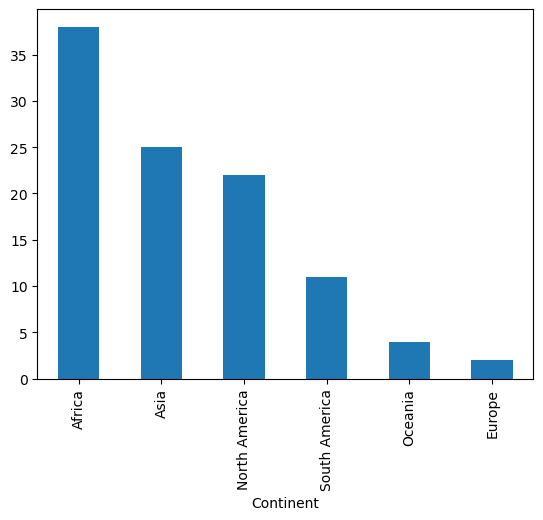

In [16]:
df['Continent'].value_counts().plot(kind='bar')

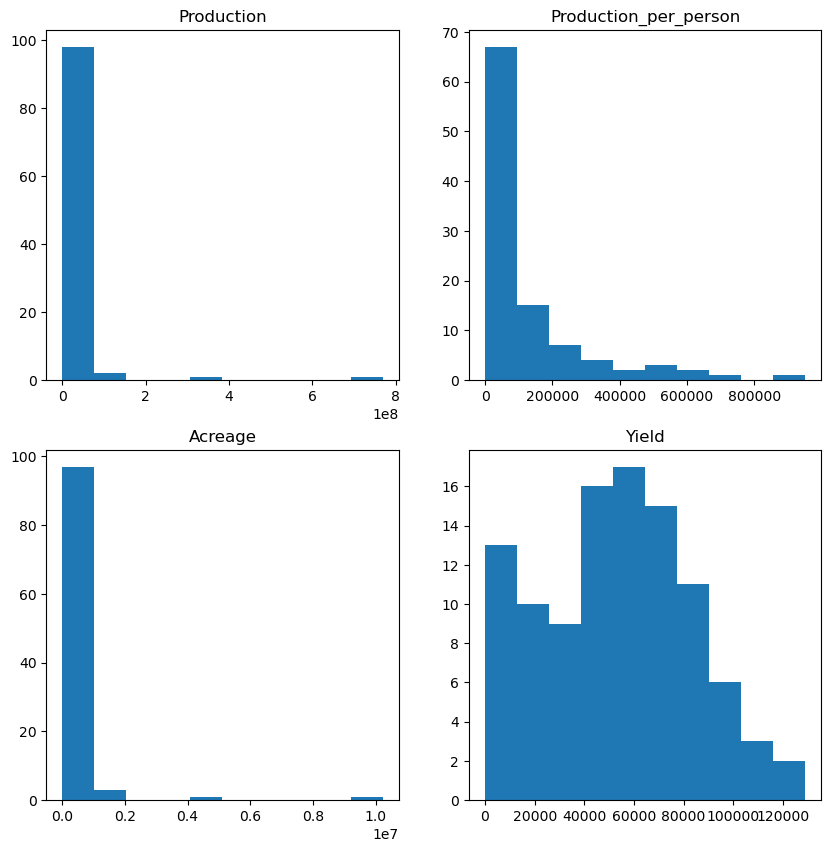

In [17]:
## matplotlib based 

fig , ax = plt.subplots(2,2 , figsize = (10,10))
ax[0,0].hist(df['Production(Tons)'] , bins = 10)
ax[0,0].set_title('Production')

ax[0,1].hist(df['Production_per_Person(Kg)'], bins = 10)
ax[0,1].set_title('Production_per_person')

ax[1,0].hist(df['Acreage(Hectare)'], bins = 10)
ax[1,0].set_title('Acreage')

ax[1,1].hist(df['Yield(Kg/Hectare)'] , bins = 10)
ax[1,1].set_title('Yield')

plt.show()




C:\Users\Darsh\AppData\Local\Temp\ipykernel_4964\38103673.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production(Tons)'])
C:\Users\Darsh\AppData\Local\Temp\ipykernel_4964\38103673.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production_per_Person(Kg)'])
C:\Users\Darsh\AppD

<Axes: xlabel='Acreage(Hectare)', ylabel='Density'>

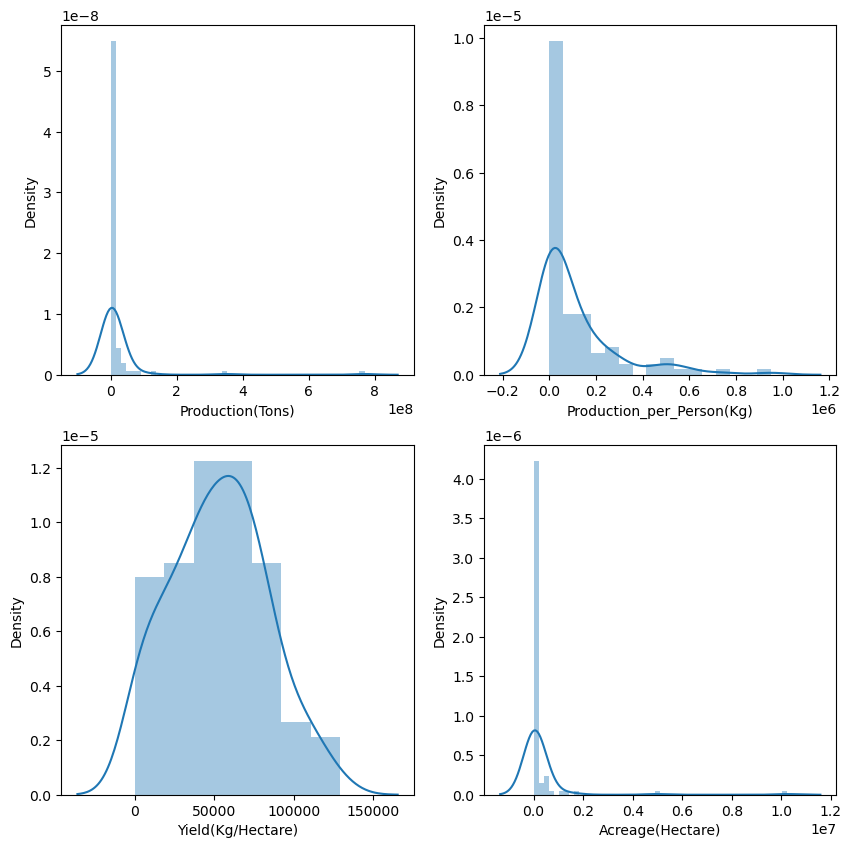

In [18]:
## seaborn 
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.distplot(df['Production(Tons)'])

plt.subplot(2,2,2)
sns.distplot(df['Production_per_Person(Kg)'])

plt.subplot(2,2,3)
sns.distplot(df['Yield(Kg/Hectare)'])

plt.subplot(2,2,4)
sns.distplot(df['Acreage(Hectare)'])

### Checking outliers

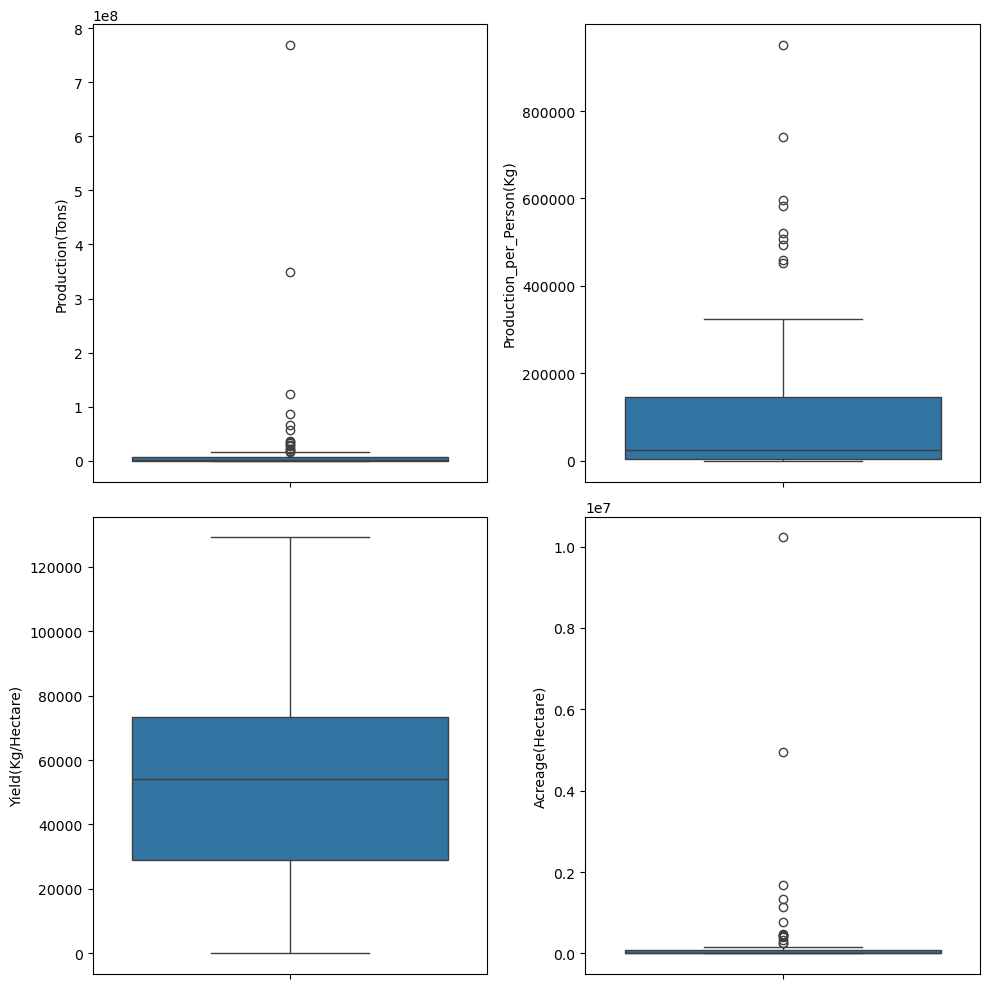

In [19]:
plt.figure(figsize=(10 ,10))

plt.subplot(2,2,1)
sns.boxplot(df['Production(Tons)'])

plt.subplot(2,2,2)
sns.boxplot(df['Production_per_Person(Kg)'])

plt.subplot(2,2,3)
sns.boxplot(df['Yield(Kg/Hectare)'])

plt.subplot(2,2,4)
sns.boxplot(df['Acreage(Hectare)'])

plt.tight_layout()
plt.show()


In [20]:
df.describe()

,Unnamed: 0,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,102.000000,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,50.529412,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,29.638985,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,0.000000,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,25.250000,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,50.500000,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,75.750000,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,102.000000,7.686784e+08,951087.000000,1.022620e+07,129049.300000


# Bivariate Analysis

In [21]:
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


### which country produces the highest number of sugarcane

In [22]:
df_new = df[['Country' , 'Production(Tons)']].copy()

In [23]:
df_new.set_index('Country')

,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0
...,...
Spain,394.0
Lebanon,97.0
Singapore,50.0


In [24]:
df_new['Percentage'] = (df_new['Production(Tons)']/df_new['Production(Tons)'].sum())*100

In [25]:
df_new

,Country,Production(Tons),Percentage
0,Brazil,768678382.0,4.072729e+01
1,India,348448000.0,1.846200e+01
2,China,123059739.0,6.520138e+00
3,Thailand,87468496.0,4.634389e+00
4,Pakistan,65450704.0,3.467809e+00
...,...,...,...
97,Spain,394.0,2.087551e-05
98,Lebanon,97.0,5.139401e-06
100,Singapore,50.0,2.649176e-06
101,Samoa,12.0,6.358022e-07


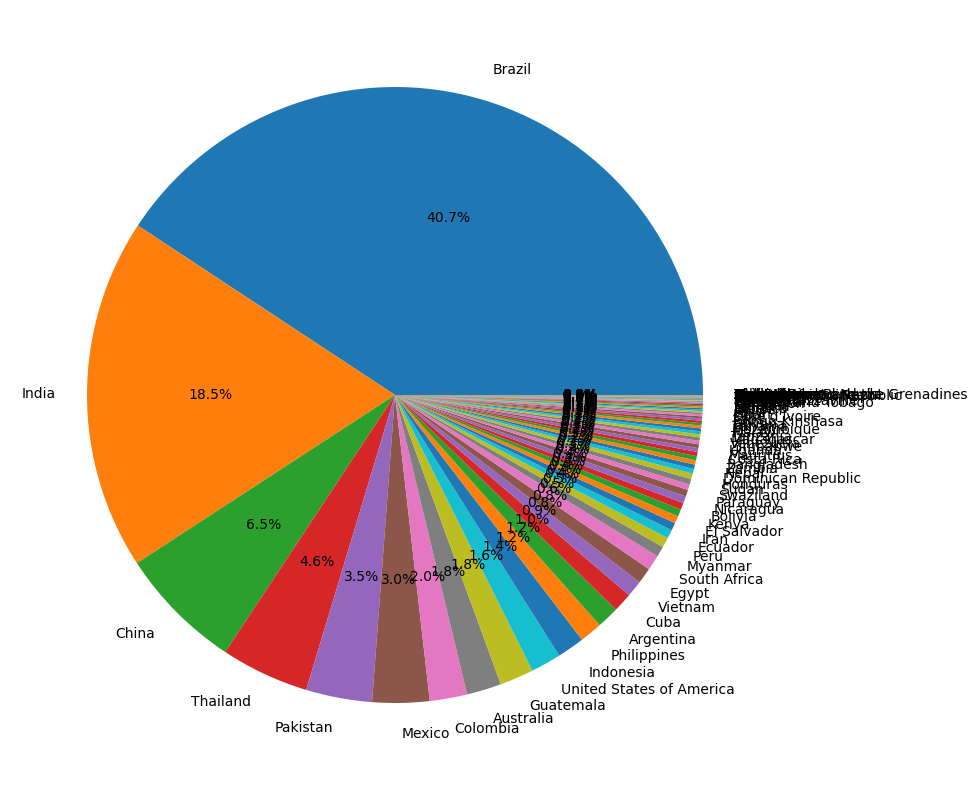

In [26]:
fig = plt.figure(figsize=(10,10))
plt.pie(df_new['Percentage'],labels=df_new['Country'] , autopct='%.1f%%' )
plt.show()

In [27]:
## breaking into small parts 
df_sorted = df_new.sort_values(by='Percentage', ascending=False)
df_final = df_sorted.iloc[:5,:].reset_index().copy()
other = df_sorted.iloc[5:,1].sum()
other_percentage = (other/df_sorted['Production(Tons)'].sum())*100
df_final.set_index('Country')
df_final.drop('index' , axis=1 , inplace=True)
df_final.loc[len(df_final)] = ['Others' , other , other_percentage]
df_final


,Country,Production(Tons),Percentage
0,Brazil,768678382.0,40.727285
1,India,348448000.0,18.462001
2,China,123059739.0,6.520138
3,Thailand,87468496.0,4.634389
4,Pakistan,65450704.0,3.467809
5,Others,494274046.0,26.188378


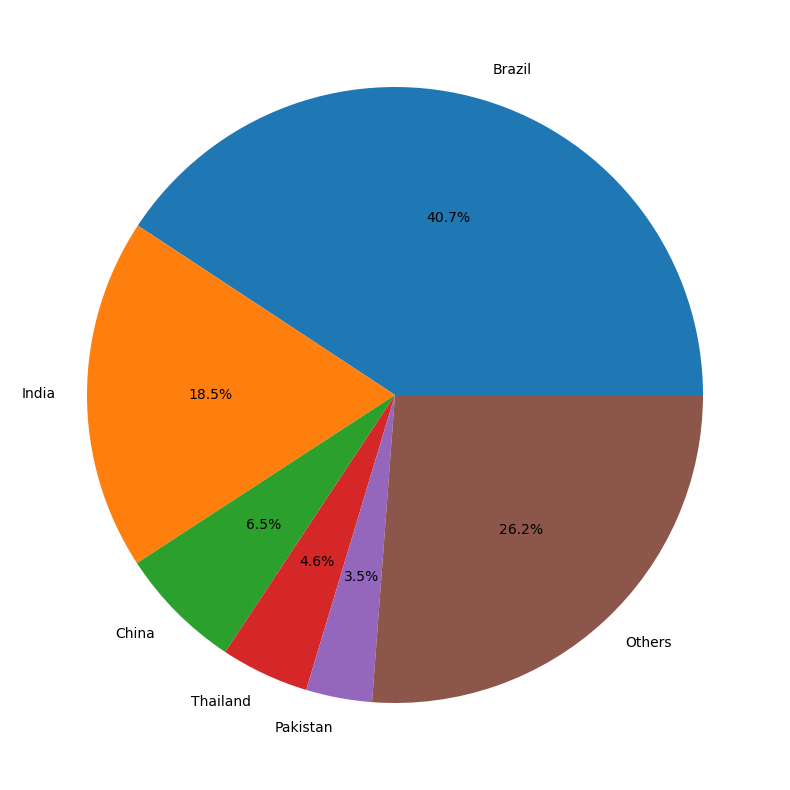

In [28]:
fig = plt.figure(figsize=(10,10))
plt.pie(df_final['Percentage'],labels=df_final['Country'] , autopct='%.1f%%' )
plt.show()

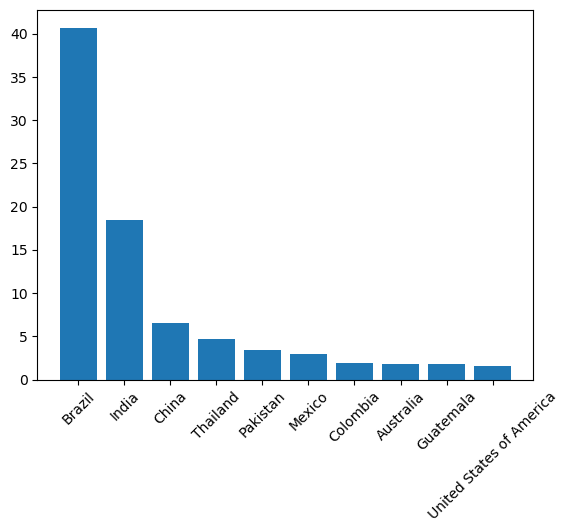

In [29]:
plt.bar(df_sorted['Country'].head(10) , df_sorted['Percentage'].head(10) )
plt.xticks(rotation=45)
plt.show()


### which country has highest land

In [30]:
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


In [31]:
df_land = df[['Country' , 'Acreage(Hectare)']].copy()
df_land = df_land.sort_values(by='Acreage(Hectare)' , ascending=False)
df_land

,Country,Acreage(Hectare)
0,Brazil,10226205.0
1,India,4950000.0
2,China,1675215.0
3,Thailand,1336575.0
4,Pakistan,1130820.0
...,...,...
97,Spain,9.0
98,Lebanon,3.0
100,Singapore,2.0
101,Samoa,1.0


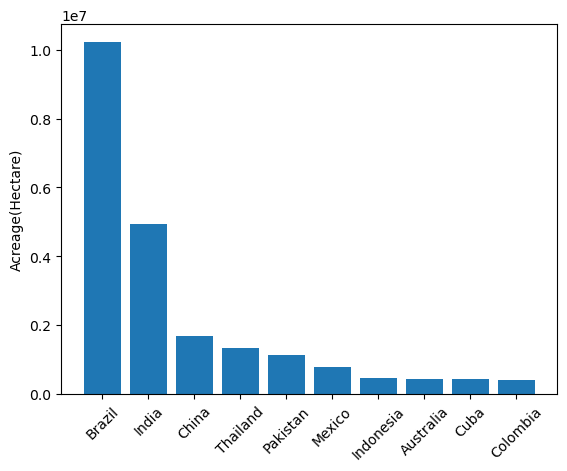

In [32]:
plt.bar(df_land['Country'].head(10) , df_land['Acreage(Hectare)'].head(10) )
plt.xticks(rotation=45)
plt.ylabel("Acreage(Hectare)")
plt.show()


### which country has highest yield kg per hectare

In [33]:
df_yield = df[['Country' , "Yield(Kg/Hectare)"]].copy()

df_yield.sort_values('Yield(Kg/Hectare)' , ascending=False , inplace=True)
df_yield.set_index('Country')



,Yield(Kg/Hectare)
Country,
Guatemala,129049.3
Senegal,118085.3
Egypt,115030.6
Peru,112120.2
Malawi,107629.5
...,...
Saint Lucia,80.0
Trinidad and Tobago,54.0
Singapore,25.0


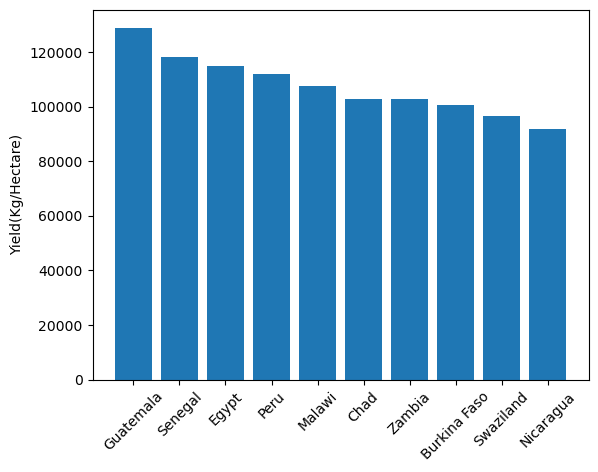

In [34]:
plt.bar(df_yield['Country'].head(10) , df_yield['Yield(Kg/Hectare)'].head(10) )
plt.xticks(rotation=45)
plt.ylabel("Yield(Kg/Hectare)")
plt.show()

In [35]:
df_yield = df[['Country' , "Production(Tons)"]].copy()

df_yield.sort_values('Production(Tons)' , ascending=False , inplace=True)
df_yield.set_index('Country')

,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0
...,...
Lebanon,97.0
Singapore,50.0
Samoa,12.0


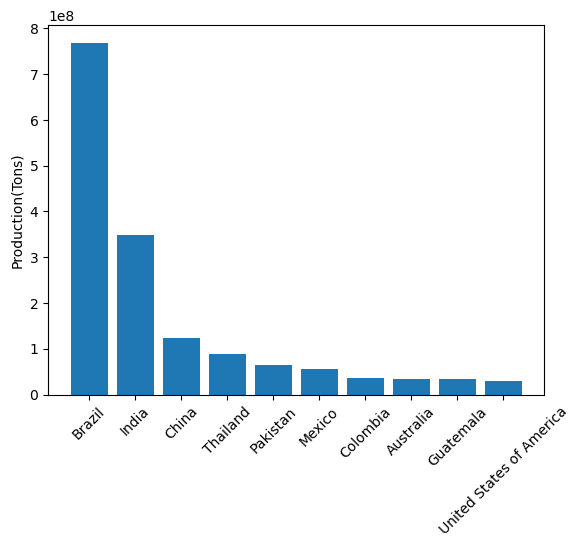

In [36]:
plt.bar(df_yield['Country'].head(10) , df_yield['Production(Tons)'].head(10) )
plt.xticks(rotation=45)
plt.ylabel("Production(Tons)")
plt.show()

### correlation 

In [37]:
df.corr(numeric_only=True)

,Unnamed: 0,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Unnamed: 0,1.000000,-0.341806,-0.372256,-0.338820,-0.475832
Production(Tons),-0.341806,1.000000,0.015000,0.997550,0.132812
Production_per_Person(Kg),-0.372256,0.015000,1.000000,0.012557,0.017999
Acreage(Hectare),-0.338820,0.997550,0.012557,1.000000,0.113433
Yield(Kg/Hectare),-0.475832,0.132812,0.017999,0.113433,1.000000


<Axes: >

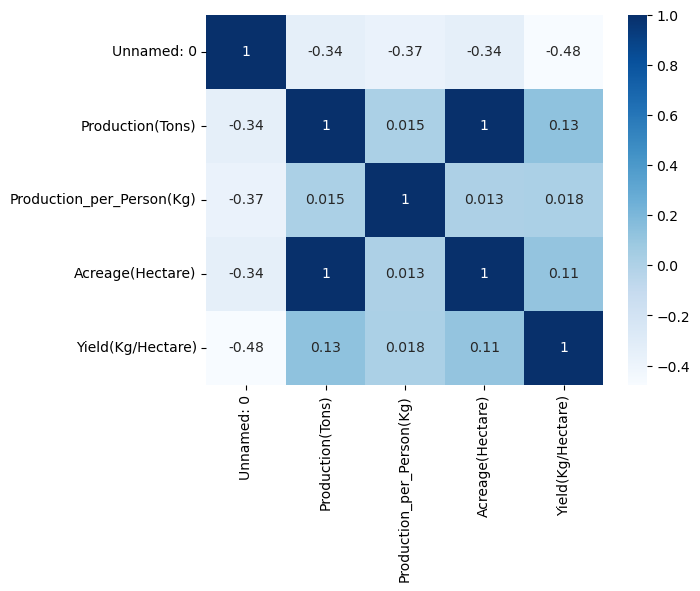

In [38]:
sns.heatmap(df.corr(numeric_only=True ) , cmap='Blues' , annot=True)

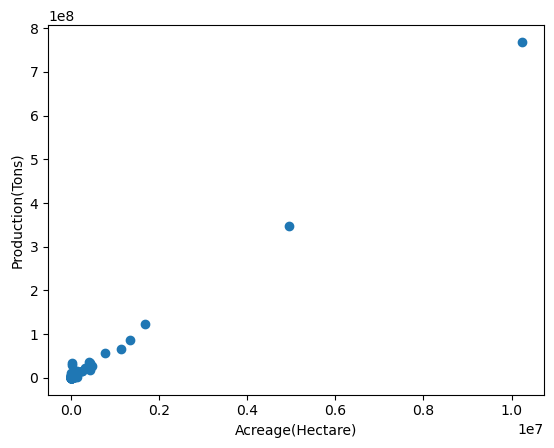

In [39]:
plt.scatter(df['Acreage(Hectare)'] , df['Production(Tons)'])
plt.xlabel('Acreage(Hectare)')
plt.ylabel('Production(Tons)')
plt.show()

### continent analysis

In [40]:
df_continents = df.groupby(by='Continent').sum()

In [41]:
df_continents.drop(['Unnamed: 0' , 'Country'] , axis=1 , inplace=True)

In [42]:
df_continents.corr(numeric_only=True)

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Production(Tons),1.000000,0.522211,0.994897,0.091201
Production_per_Person(Kg),0.522211,1.000000,0.463215,0.542961
Acreage(Hectare),0.994897,0.463215,1.000000,0.111166
Yield(Kg/Hectare),0.091201,0.542961,0.111166,1.000000


In [43]:
df_continents.sort_values(by='Production(Tons)' , ascending=False ,inplace=True)

<BarContainer object of 6 artists>

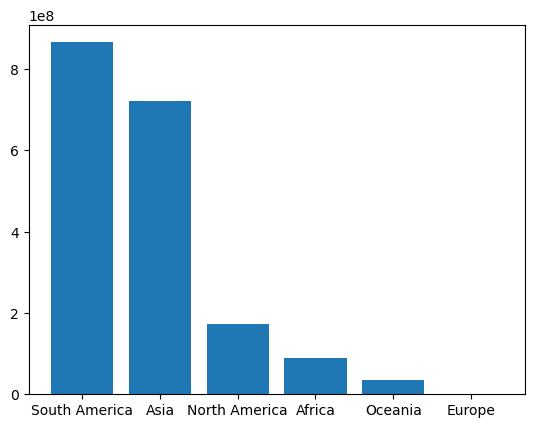

In [44]:
df_continents = df_continents.reset_index()
plt.bar(df_continents['Continent'] , df_continents['Production(Tons)'])

In [51]:
df_continents['Number_of_countries'] = df.groupby('Continent')['Country'].count()

In [58]:
df_continents['Number_of_countries'] =df_continents['Continent'].map(df.groupby('Continent')['Country'].count())

In [59]:
df_continents

,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare),Number_of_countries
0,South America,865588126.0,3505531.738,11369236.0,677192.7,11
1,Asia,721930425.0,1857769.303,10608319.0,1171871.4,25
2,North America,173995947.0,3796081.508,1581983.0,1082602.4,22
3,Africa,89681472.0,2332636.293,1439089.0,2142107.5,38
4,Oceania,36177574.0,28593.605,490909.0,162419.1,4
5,Europe,5823.0,536.000,71.0,131870.9,2


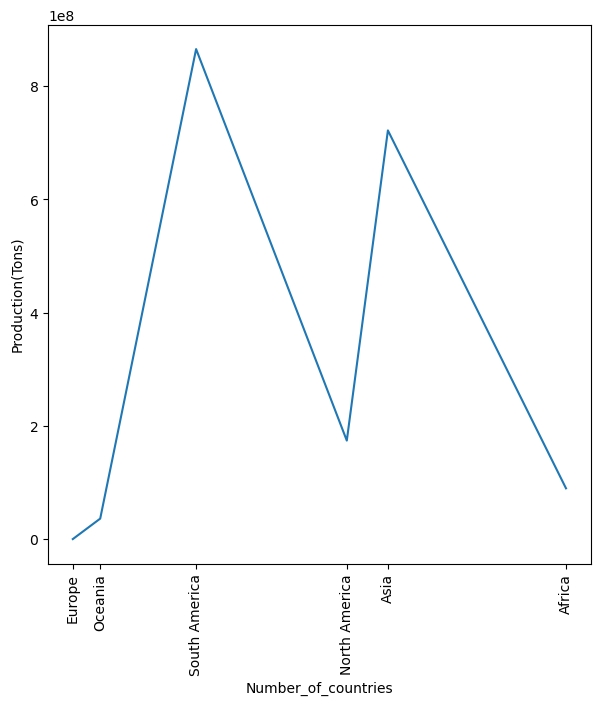

In [76]:
fig = plt.figure(figsize=(7,7))
sns.lineplot(data=df_continents ,x='Number_of_countries' , y='Production(Tons)')
plt.xticks(df_continents['Number_of_countries'] , df_continents['Continent'].values , rotation=90)
plt.show()